# 02 - Synthetic Greenhouse Data Generator

**Purpose:** Generate realistic synthetic time-series data for greenhouse sensors, with stage-aware profiles, realistic inter-variable relationships, noise, drift, and event injections.

**What it produces:**
- 30 days of 5-minute resolution sensor data
- Hourly downsampled version
- Synthetic events log (irrigation, ventilation, etc.)
- CSV exports to `data/` folder

**Sensors simulated:**
- Environmental: air_temperature (°C), relative_humidity (%), light_lux, co2_ppm
- Soil: soil_moisture (%), soil_ph, soil_ec (mS/cm)
- Derived: leaf_wetness (0-1 proxy), ventilation_rate (0-1), air_circulation (0-1)

**Growth stages:** Vegetative → Flowering → Fruiting → Harvest (for tomato and strawberry)

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import json

# Set random seed
np.random.seed(42)

# Paths
DATA_DIR = 'data'
FIGURES_DIR = 'figures'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✓ Imports complete")

✓ Imports complete


## 1. Define Growth Stage Profiles

Each growth stage has different environmental targets and tolerances.

In [2]:
# Growth stage definitions for tomato
TOMATO_STAGES = {
    'vegetative': {
        'duration_days': 10,
        'temp_target': 22.0,
        'temp_range': 3.0,
        'humidity_target': 70.0,
        'humidity_range': 10.0,
        'light_target': 15000,
        'light_range': 5000,
        'co2_target': 800,
        'soil_moisture_target': 65.0,
        'soil_ph_target': 6.2,
        'soil_ec_target': 2.0
    },
    'flowering': {
        'duration_days': 8,
        'temp_target': 20.0,
        'temp_range': 2.5,
        'humidity_target': 65.0,
        'humidity_range': 8.0,
        'light_target': 18000,
        'light_range': 4000,
        'co2_target': 1000,
        'soil_moisture_target': 60.0,
        'soil_ph_target': 6.0,
        'soil_ec_target': 2.2
    },
    'fruiting': {
        'duration_days': 8,
        'temp_target': 21.0,
        'temp_range': 2.5,
        'humidity_target': 60.0,
        'humidity_range': 10.0,
        'light_target': 20000,
        'light_range': 5000,
        'co2_target': 1200,
        'soil_moisture_target': 70.0,
        'soil_ph_target': 6.3,
        'soil_ec_target': 2.5
    },
    'harvest': {
        'duration_days': 4,
        'temp_target': 20.0,
        'temp_range': 3.0,
        'humidity_target': 55.0,
        'humidity_range': 10.0,
        'light_target': 17000,
        'light_range': 4000,
        'co2_target': 900,
        'soil_moisture_target': 55.0,
        'soil_ph_target': 6.1,
        'soil_ec_target': 2.3
    }
}

# Create stage timeline
def create_stage_timeline(stages_dict, total_days=30):
    """
    Create a timeline mapping each day to a growth stage.
    """
    stage_names = list(stages_dict.keys())
    timeline = []
    current_day = 0
    
    while current_day < total_days:
        for stage_name in stage_names:
            stage_duration = stages_dict[stage_name]['duration_days']
            for _ in range(stage_duration):
                if current_day < total_days:
                    timeline.append(stage_name)
                    current_day += 1
                else:
                    break
            if current_day >= total_days:
                break
    
    return timeline

stage_timeline = create_stage_timeline(TOMATO_STAGES, total_days=30)
print(f"✓ Stage timeline created: {len(stage_timeline)} days")
print(f"  Stages: {set(stage_timeline)}")

✓ Stage timeline created: 30 days
  Stages: {'flowering', 'fruiting', 'vegetative', 'harvest'}


## 2. Synthetic Data Generator Class

Generates realistic time-series with:
- Diurnal (day/night) patterns
- Stage-aware target values
- Inter-variable relationships
- Noise, drift, and missing values
- Event injections (irrigation, ventilation changes)

In [3]:
class GreenhouseDataGenerator:
    """
    Generate synthetic greenhouse sensor data with realistic patterns.
    """
    
    def __init__(self, start_date, days=30, freq_minutes=5, stages_dict=None, stage_timeline=None):
        self.start_date = pd.to_datetime(start_date)
        self.days = days
        self.freq_minutes = freq_minutes
        self.stages_dict = stages_dict or TOMATO_STAGES
        self.stage_timeline = stage_timeline or create_stage_timeline(self.stages_dict, days)
        
        # Create timestamp index
        self.timestamps = pd.date_range(
            start=self.start_date,
            periods=int(days * 24 * 60 / freq_minutes),
            freq=f'{freq_minutes}min'
        )
        
        self.n_samples = len(self.timestamps)
        self.data = pd.DataFrame({'timestamp': self.timestamps})
        self.events = []  # Log of synthetic events
        
    def get_stage_at_time(self, timestamp_idx):
        """Get growth stage for a given timestamp index."""
        day_idx = int(timestamp_idx * self.freq_minutes / (24 * 60))
        return self.stage_timeline[min(day_idx, len(self.stage_timeline) - 1)]
    
    def get_stage_params(self, timestamp_idx):
        """Get stage parameters for a given timestamp."""
        stage = self.get_stage_at_time(timestamp_idx)
        return self.stages_dict[stage]
    
    def diurnal_pattern(self, hour, peak_hour=14, amplitude=1.0, baseline=0.0):
        """Generate diurnal (day/night) pattern."""
        # Cosine pattern peaking at peak_hour
        phase = 2 * np.pi * (hour - peak_hour) / 24
        return baseline + amplitude * np.cos(phase)
    
    def generate_light(self):
        """Generate light intensity with day/night cycle."""
        light = np.zeros(self.n_samples)
        
        for i, ts in enumerate(self.timestamps):
            hour = ts.hour + ts.minute / 60
            params = self.get_stage_params(i)
            
            # Day/night cycle: light only during ~6am to 8pm
            if 6 <= hour <= 20:
                # Peak at 2pm
                diurnal = self.diurnal_pattern(hour, peak_hour=14, amplitude=0.5, baseline=0.5)
                light[i] = params['light_target'] * diurnal
            else:
                light[i] = 0
            
            # Add noise
            noise = np.random.normal(0, params['light_range'] * 0.1)
            light[i] = max(0, light[i] + noise)
        
        self.data['light_lux'] = light
        return light
    
    def generate_temperature(self, light):
        """Generate temperature influenced by light and ventilation."""
        temp = np.zeros(self.n_samples)
        
        for i, ts in enumerate(self.timestamps):
            hour = ts.hour + ts.minute / 60
            params = self.get_stage_params(i)
            
            # Base temperature with diurnal variation
            diurnal = self.diurnal_pattern(hour, peak_hour=15, amplitude=params['temp_range'] * 0.5, baseline=0)
            
            # Light influence (heating)
            light_effect = (light[i] / 20000) * 2.0  # Up to +2°C from light
            
            temp[i] = params['temp_target'] + diurnal + light_effect
            
            # Add noise
            noise = np.random.normal(0, 0.3)
            temp[i] += noise
        
        self.data['air_temperature'] = temp
        return temp
    
    def generate_ventilation_and_circulation(self):
        """Generate actuator states for ventilation and air circulation."""
        vent = np.zeros(self.n_samples)
        circ = np.zeros(self.n_samples)
        
        # Base pattern: higher during day, lower at night
        for i, ts in enumerate(self.timestamps):
            hour = ts.hour + ts.minute / 60
            
            # Ventilation higher during day
            if 8 <= hour <= 18:
                vent[i] = 0.6 + np.random.uniform(-0.1, 0.2)
            else:
                vent[i] = 0.3 + np.random.uniform(-0.1, 0.1)
            
            # Circulation more constant
            circ[i] = 0.5 + np.random.uniform(-0.1, 0.1)
            
            # Clamp to [0, 1]
            vent[i] = np.clip(vent[i], 0, 1)
            circ[i] = np.clip(circ[i], 0, 1)
        
        # Inject some ventilation change events
        n_events = 15
        event_indices = np.random.choice(self.n_samples, n_events, replace=False)
        for idx in event_indices:
            # Sudden ventilation increase
            change_duration = np.random.randint(6, 36)  # 30 min to 3 hours
            for j in range(idx, min(idx + change_duration, self.n_samples)):
                vent[j] = min(1.0, vent[j] + 0.3)
            
            self.events.append({
                'timestamp': self.timestamps[idx],
                'event_type': 'ventilation_increase',
                'duration_minutes': change_duration * self.freq_minutes
            })
        
        self.data['ventilation_rate'] = vent
        self.data['air_circulation'] = circ
        return vent, circ
    
    def generate_humidity(self, temp, vent):
        """Generate humidity inversely related to ventilation and temperature."""
        humidity = np.zeros(self.n_samples)
        
        for i, ts in enumerate(self.timestamps):
            hour = ts.hour + ts.minute / 60
            params = self.get_stage_params(i)
            
            # Base humidity with diurnal (higher at night)
            diurnal = self.diurnal_pattern(hour, peak_hour=4, amplitude=params['humidity_range'] * 0.3, baseline=0)
            
            # Inverse relationship with ventilation
            vent_effect = -10 * (vent[i] - 0.5)  # Lower humidity when vent is high
            
            # Inverse relationship with temperature
            temp_effect = -(temp[i] - params['temp_target']) * 0.8
            
            humidity[i] = params['humidity_target'] + diurnal + vent_effect + temp_effect
            
            # Add noise and drift
            noise = np.random.normal(0, 2.0)
            drift = 0.001 * i  # Slow humidity sensor drift
            humidity[i] += noise + drift
            
            # Clamp to realistic range
            humidity[i] = np.clip(humidity[i], 30, 95)
        
        self.data['relative_humidity'] = humidity
        return humidity
    
    def generate_co2(self, vent):
        """Generate CO2 influenced by ventilation and injection events."""
        co2 = np.zeros(self.n_samples)
        
        for i, ts in enumerate(self.timestamps):
            params = self.get_stage_params(i)
            
            # Base CO2 inversely related to ventilation
            vent_effect = -200 * (vent[i] - 0.5)
            
            co2[i] = params['co2_target'] + vent_effect
            
            # Add noise
            noise = np.random.normal(0, 50)
            co2[i] += noise
            co2[i] = max(400, co2[i])  # Atmospheric minimum
        
        # Inject CO2 enrichment events
        n_co2_events = 10
        event_indices = np.random.choice(self.n_samples, n_co2_events, replace=False)
        for idx in event_indices:
            duration = np.random.randint(6, 24)  # 30 min to 2 hours
            for j in range(idx, min(idx + duration, self.n_samples)):
                co2[j] = min(1500, co2[j] + 200)
            
            self.events.append({
                'timestamp': self.timestamps[idx],
                'event_type': 'co2_injection',
                'duration_minutes': duration * self.freq_minutes
            })
        
        self.data['co2_ppm'] = co2
        return co2
    
    def generate_soil_moisture(self):
        """Generate soil moisture with irrigation events."""
        soil_moisture = np.zeros(self.n_samples)
        
        # Start at target
        current_moisture = self.get_stage_params(0)['soil_moisture_target']
        
        # Decay rate (water usage by plants)
        decay_per_step = 0.15  # % per 5 minutes
        
        for i, ts in enumerate(self.timestamps):
            params = self.get_stage_params(i)
            
            # Natural decay
            current_moisture -= decay_per_step
            
            # Irrigation trigger
            if current_moisture < params['soil_moisture_target'] - 10:
                # Irrigation event
                irrigation_amount = np.random.uniform(15, 25)
                current_moisture += irrigation_amount
                
                self.events.append({
                    'timestamp': self.timestamps[i],
                    'event_type': 'irrigation',
                    'amount_increase': irrigation_amount
                })
            
            # Add noise
            noise = np.random.normal(0, 0.5)
            soil_moisture[i] = np.clip(current_moisture + noise, 20, 95)
            current_moisture = soil_moisture[i]
        
        self.data['soil_moisture'] = soil_moisture
        return soil_moisture
    
    def generate_soil_ph_ec(self):
        """Generate soil pH and EC with slow drift."""
        soil_ph = np.zeros(self.n_samples)
        soil_ec = np.zeros(self.n_samples)
        
        for i in range(self.n_samples):
            params = self.get_stage_params(i)
            
            # pH: slow drift + noise
            drift_ph = 0.0001 * i
            noise_ph = np.random.normal(0, 0.1)
            soil_ph[i] = params['soil_ph_target'] + drift_ph + noise_ph
            soil_ph[i] = np.clip(soil_ph[i], 5.0, 7.5)
            
            # EC: slow drift + noise
            drift_ec = 0.00005 * i
            noise_ec = np.random.normal(0, 0.05)
            soil_ec[i] = params['soil_ec_target'] + drift_ec + noise_ec
            soil_ec[i] = np.clip(soil_ec[i], 1.0, 3.5)
        
        self.data['soil_ph'] = soil_ph
        self.data['soil_ec'] = soil_ec
        return soil_ph, soil_ec
    
    def generate_leaf_wetness(self, humidity, temp):
        """Generate leaf wetness proxy (0-1) based on humidity and temperature."""
        leaf_wetness = np.zeros(self.n_samples)
        
        for i in range(self.n_samples):
            # High humidity + low temp = high leaf wetness
            if humidity[i] > 75 and temp[i] < 18:
                leaf_wetness[i] = 0.7 + np.random.uniform(0, 0.3)
            elif humidity[i] > 70:
                leaf_wetness[i] = 0.4 + np.random.uniform(0, 0.3)
            elif humidity[i] > 60:
                leaf_wetness[i] = 0.2 + np.random.uniform(0, 0.2)
            else:
                leaf_wetness[i] = 0.0 + np.random.uniform(0, 0.1)
            
            leaf_wetness[i] = np.clip(leaf_wetness[i], 0, 1)
        
        self.data['leaf_wetness'] = leaf_wetness
        return leaf_wetness
    
    def add_missing_values(self, missing_rate=0.02):
        """Inject missing values randomly."""
        for col in ['air_temperature', 'relative_humidity', 'soil_moisture']:
            if col in self.data.columns:
                n_missing = int(len(self.data) * missing_rate)
                missing_indices = np.random.choice(len(self.data), n_missing, replace=False)
                self.data.loc[missing_indices, col] = np.nan
        
        print(f"✓ Injected missing values (~{missing_rate*100:.1f}% per selected sensor)")
    
    def add_growth_stage_column(self):
        """Add growth stage as a column."""
        stages = [self.get_stage_at_time(i) for i in range(self.n_samples)]
        self.data['growth_stage'] = stages
    
    def generate_all(self):
        """Generate complete dataset."""
        print("Generating synthetic greenhouse data...")
        
        # Generate in dependency order
        light = self.generate_light()
        print("  ✓ Light")
        
        vent, circ = self.generate_ventilation_and_circulation()
        print("  ✓ Ventilation & Circulation")
        
        temp = self.generate_temperature(light)
        print("  ✓ Temperature")
        
        humidity = self.generate_humidity(temp, vent)
        print("  ✓ Humidity")
        
        co2 = self.generate_co2(vent)
        print("  ✓ CO2")
        
        soil_moisture = self.generate_soil_moisture()
        print("  ✓ Soil Moisture")
        
        soil_ph, soil_ec = self.generate_soil_ph_ec()
        print("  ✓ Soil pH & EC")
        
        leaf_wetness = self.generate_leaf_wetness(humidity, temp)
        print("  ✓ Leaf Wetness")
        
        self.add_growth_stage_column()
        print("  ✓ Growth Stage")
        
        self.add_missing_values(missing_rate=0.015)
        
        print(f"\n✓ Generated {len(self.data)} samples ({self.days} days at {self.freq_minutes}-min resolution)")
        print(f"✓ Logged {len(self.events)} synthetic events")
        
        return self.data, self.events

print("✓ GreenhouseDataGenerator class defined")

✓ GreenhouseDataGenerator class defined


## 3. Generate Synthetic Data

Create the complete 30-day dataset at 5-minute resolution.

In [5]:
# Initialize generator
generator = GreenhouseDataGenerator(
    start_date='2026-01-01',
    days=30,
    freq_minutes=5,
    stages_dict=TOMATO_STAGES,
    stage_timeline=stage_timeline
)

# Generate data
df_5min, events_log = generator.generate_all()

# Display summary
print("\n" + "="*60)
print("Dataset Summary:")
print("="*60)
print(df_5min.info())
print("\n")
print(df_5min.describe())

Generating synthetic greenhouse data...
  ✓ Light


  ✓ Ventilation & Circulation
  ✓ Temperature
  ✓ Humidity
  ✓ CO2
  ✓ Soil Moisture
  ✓ Soil pH & EC
  ✓ Leaf Wetness
  ✓ Growth Stage
✓ Injected missing values (~1.5% per selected sensor)

✓ Generated 8640 samples (30 days at 5-min resolution)
✓ Logged 86 synthetic events

Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 8640 entries, 0 to 8639
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          8640 non-null   datetime64[us]
 1   light_lux          8640 non-null   float64       
 2   ventilation_rate   8640 non-null   float64       
 3   air_circulation    8640 non-null   float64       
 4   air_temperature    8511 non-null   float64       
 5   relative_humidity  8511 non-null   float64       
 6   co2_ppm            8640 non-null   float64       
 7   soil_moisture      8511 non-null   float64       
 8   soil_ph            8640 non-null   float64       
 9   s

## 4. Create Hourly Downsampled Version

In [7]:
# Downsample to hourly
df_hourly = df_5min.set_index('timestamp').resample('1h').agg({
    'air_temperature': 'mean',
    'relative_humidity': 'mean',
    'light_lux': 'mean',
    'co2_ppm': 'mean',
    'soil_moisture': 'mean',
    'soil_ph': 'mean',
    'soil_ec': 'mean',
    'leaf_wetness': 'mean',
    'ventilation_rate': 'mean',
    'air_circulation': 'mean',
    'growth_stage': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]
}).reset_index()

print(f"✓ Created hourly dataset: {len(df_hourly)} samples")
print(df_hourly.head())

✓ Created hourly dataset: 720 samples
            timestamp  air_temperature  relative_humidity   light_lux  \
0 2026-01-01 00:00:00        20.914081          73.802290  259.093549   
1 2026-01-01 01:00:00        20.718871          75.679587  238.062213   
2 2026-01-01 02:00:00        20.655271          75.236920   93.573996   
3 2026-01-01 03:00:00        20.668893          76.847480  271.108743   
4 2026-01-01 04:00:00        20.498030          76.661475   98.545048   

      co2_ppm  soil_moisture   soil_ph   soil_ec  leaf_wetness  \
0  851.431334      63.273861  6.175936  2.030650      0.559268   
1  851.450952      62.252890  6.216212  1.976284      0.519918   
2  860.898094      59.055752  6.196219  1.993585      0.520398   
3  853.187020      58.433498  6.223539  1.999053      0.565420   
4  815.709819      74.470295  6.185867  2.020034      0.560710   

   ventilation_rate  air_circulation growth_stage  
0          0.313806         0.489271   vegetative  
1          0.297582   

## 5. Export Data to CSV

In [8]:
# Export CSVs
df_5min.to_csv(os.path.join(DATA_DIR, 'greenhouse_data_5min.csv'), index=False)
df_hourly.to_csv(os.path.join(DATA_DIR, 'greenhouse_data_hourly.csv'), index=False)

# Export events log
events_df = pd.DataFrame(events_log)
events_df.to_csv(os.path.join(DATA_DIR, 'events_log.csv'), index=False)

print("✓ Exported data files:")
print(f"  - {DATA_DIR}/greenhouse_data_5min.csv")
print(f"  - {DATA_DIR}/greenhouse_data_hourly.csv")
print(f"  - {DATA_DIR}/events_log.csv")
print(f"\n✓ Events summary: {events_df['event_type'].value_counts().to_dict()}")

✓ Exported data files:
  - data/greenhouse_data_5min.csv
  - data/greenhouse_data_hourly.csv
  - data/events_log.csv

✓ Events summary: {'irrigation': 61, 'ventilation_increase': 15, 'co2_injection': 10}


## 6. Visualization: Quick Data Quality Check

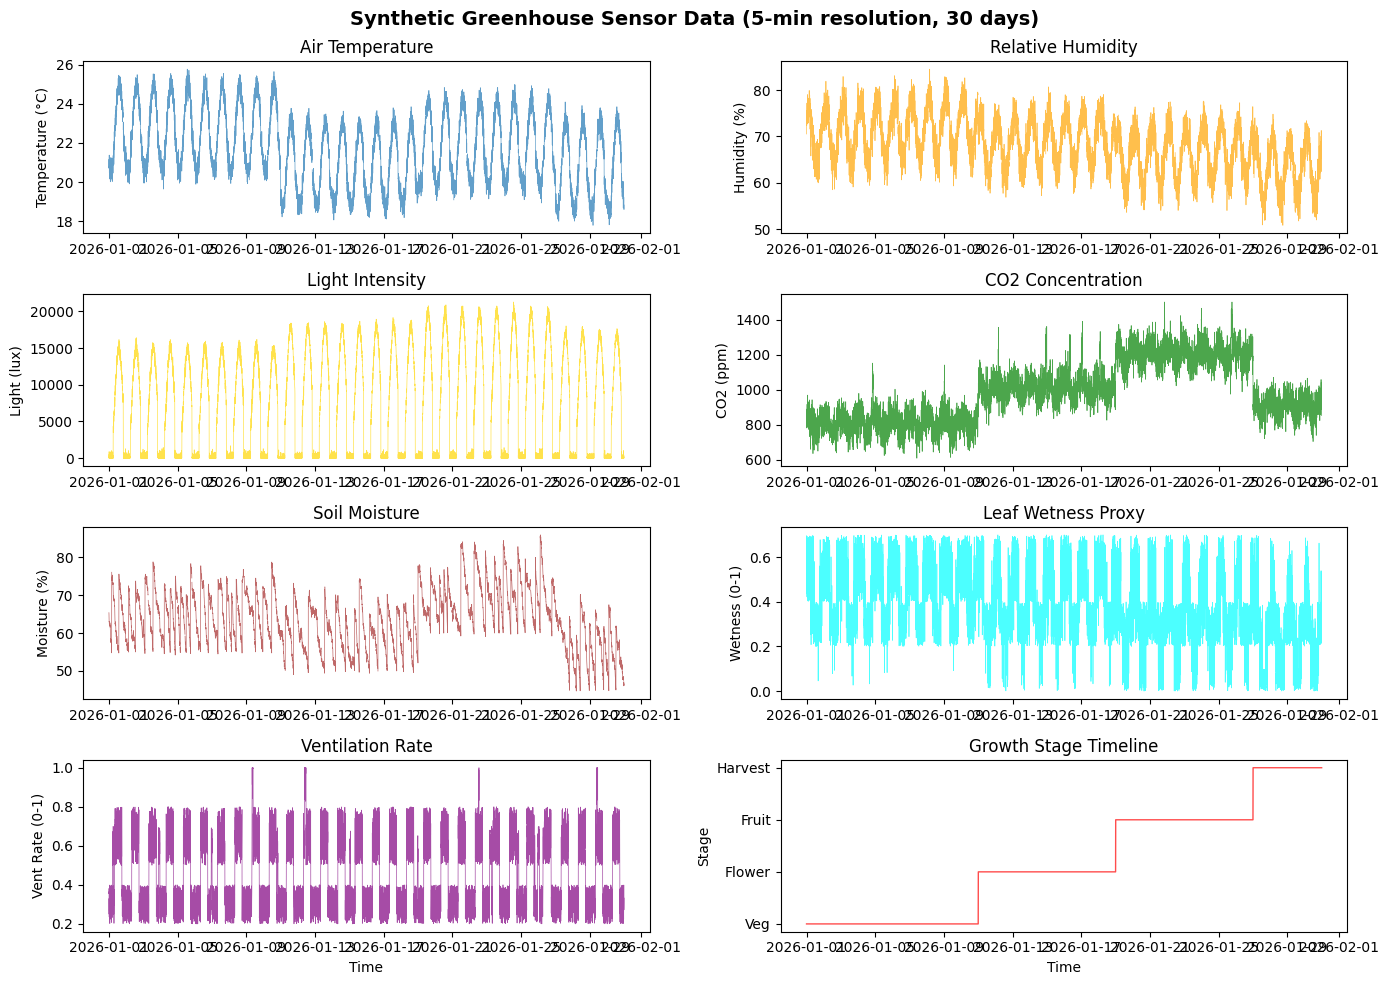

✓ Saved: figures/data_generation_overview.png


In [9]:
# Plot key sensors
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
fig.suptitle('Synthetic Greenhouse Sensor Data (5-min resolution, 30 days)', fontsize=14, fontweight='bold')

# Temperature
axes[0, 0].plot(df_5min['timestamp'], df_5min['air_temperature'], linewidth=0.5, alpha=0.7)
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].set_title('Air Temperature')

# Humidity
axes[0, 1].plot(df_5min['timestamp'], df_5min['relative_humidity'], linewidth=0.5, alpha=0.7, color='orange')
axes[0, 1].set_ylabel('Humidity (%)')
axes[0, 1].set_title('Relative Humidity')

# Light
axes[1, 0].plot(df_5min['timestamp'], df_5min['light_lux'], linewidth=0.5, alpha=0.7, color='gold')
axes[1, 0].set_ylabel('Light (lux)')
axes[1, 0].set_title('Light Intensity')

# CO2
axes[1, 1].plot(df_5min['timestamp'], df_5min['co2_ppm'], linewidth=0.5, alpha=0.7, color='green')
axes[1, 1].set_ylabel('CO2 (ppm)')
axes[1, 1].set_title('CO2 Concentration')

# Soil Moisture
axes[2, 0].plot(df_5min['timestamp'], df_5min['soil_moisture'], linewidth=0.5, alpha=0.7, color='brown')
axes[2, 0].set_ylabel('Moisture (%)')
axes[2, 0].set_title('Soil Moisture')

# Leaf Wetness
axes[2, 1].plot(df_5min['timestamp'], df_5min['leaf_wetness'], linewidth=0.5, alpha=0.7, color='cyan')
axes[2, 1].set_ylabel('Wetness (0-1)')
axes[2, 1].set_title('Leaf Wetness Proxy')

# Ventilation
axes[3, 0].plot(df_5min['timestamp'], df_5min['ventilation_rate'], linewidth=0.5, alpha=0.7, color='purple')
axes[3, 0].set_ylabel('Vent Rate (0-1)')
axes[3, 0].set_title('Ventilation Rate')
axes[3, 0].set_xlabel('Time')

# Growth Stage
stage_map = {'vegetative': 0, 'flowering': 1, 'fruiting': 2, 'harvest': 3}
stage_numeric = df_5min['growth_stage'].map(stage_map)
axes[3, 1].plot(df_5min['timestamp'], stage_numeric, linewidth=1, alpha=0.7, color='red')
axes[3, 1].set_ylabel('Stage')
axes[3, 1].set_yticks([0, 1, 2, 3])
axes[3, 1].set_yticklabels(['Veg', 'Flower', 'Fruit', 'Harvest'])
axes[3, 1].set_title('Growth Stage Timeline')
axes[3, 1].set_xlabel('Time')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'data_generation_overview.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: figures/data_generation_overview.png")

---

## Report Notes

**Notebook 02 Deliverables:**

**Data Generated:**
- ✓ 30 days of synthetic greenhouse sensor data
- ✓ 5-minute resolution: 8,640 samples
- ✓ Hourly resolution: 720 samples
- ✓ 10 sensor variables with realistic inter-relationships
- ✓ Growth stage timeline (vegetative → flowering → fruiting → harvest)

**Realistic Features:**
- ✓ Diurnal (day/night) patterns for temperature, humidity, light
- ✓ Stage-aware target profiles
- ✓ Inter-variable relationships:
  - Temperature influenced by light and ventilation
  - Humidity inversely related to ventilation and temperature
  - Leaf wetness proxy from humidity + temperature
  - CO2 influenced by ventilation and injection events
  - Soil moisture with irrigation events
- ✓ Sensor drift (humidity sensor)
- ✓ Missing values (~1.5% in selected sensors)
- ✓ Gaussian noise on all sensors

**Events Log:**
- ✓ Irrigation events (triggered by soil moisture thresholds)
- ✓ Ventilation increase events
- ✓ CO2 injection events

**Exports:**
- `data/greenhouse_data_5min.csv` (8,640 rows)
- `data/greenhouse_data_hourly.csv` (720 rows)
- `data/events_log.csv`
- `figures/data_generation_overview.png`

**Next Steps:** Proceed to Notebook 03 to implement disease risk indexing and growth stage detection.